In [4]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import timm
import numpy as np
import cv2
import sys
from tqdm import tqdm
hornet_path = r"HorNet-master"
sys.path.append(hornet_path)

from hornet import hornet_tiny_gf 


C:\Users\JARE WORKS\AppData\Roaming\Python\Python312\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\JARE WORKS\AppData\Roaming\Python\Python312\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [2]:
train_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Training'
test_path = 'C:/Users/JARE WORKS/Documents/aj project/ovie results/archive (3)/Testing'
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = ImageFolder(root=train_path, transform=transform)
test_dataset = ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('hornet_tiny_gf', pretrained=True)
model.head = nn.Linear(model.head.in_features, len(class_names))  # Adjust for 4 classes
model = model.to(device)


[gnconv] 2 order with dims= [32, 64] scale=0.3333
[gnconv] 2 order with dims= [32, 64] scale=0.3333
[gnconv] 3 order with dims= [32, 64, 128] scale=0.3333
[gnconv] 3 order with dims= [32, 64, 128] scale=0.3333
[gnconv] 3 order with dims= [32, 64, 128] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 orde

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [7]:
#train 
train_losses = []
train_accuracies = []

def train(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), correct / total


In [8]:
# validation 
def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, 1).cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_probs)
    


In [9]:
num_epochs = 5

for epoch in range(num_epochs):
    loss, acc = train(model, train_loader, optimizer, criterion)
    
    train_losses.append(loss)
    train_accuracies.append(acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}, Accuracy: {acc:.4f}")


100%|██████████| 179/179 [34:29<00:00, 11.56s/it]


Epoch [1/5], Loss: 1.2726, Accuracy: 0.3899


100%|██████████| 179/179 [30:56<00:00, 10.37s/it]


Epoch [2/5], Loss: 1.0510, Accuracy: 0.5574


100%|██████████| 179/179 [31:16<00:00, 10.48s/it]


Epoch [3/5], Loss: 0.7382, Accuracy: 0.7087


100%|██████████| 179/179 [33:50<00:00, 11.35s/it]


Epoch [4/5], Loss: 0.4321, Accuracy: 0.8368


100%|██████████| 179/179 [35:11<00:00, 11.80s/it]

Epoch [5/5], Loss: 0.2727, Accuracy: 0.8957


In [10]:
y_true, y_pred, y_probs = evaluate(model, test_loader)

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Accuracy Score:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))


Classification Report:
               precision    recall  f1-score   support

      glioma       0.88      0.73      0.80       300
  meningioma       0.74      0.70      0.72       306
     notumor       0.90      0.99      0.94       405
   pituitary       0.91      0.98      0.94       300

    accuracy                           0.86      1311
   macro avg       0.86      0.85      0.85      1311
weighted avg       0.86      0.86      0.86      1311

Confusion Matrix:
 [[220  69   1  10]
 [ 27 215  45  19]
 [  2   2 401   0]
 [  1   5   0 294]]
Accuracy Score: 0.8619374523264683
F1 Score: 0.8579561188651249


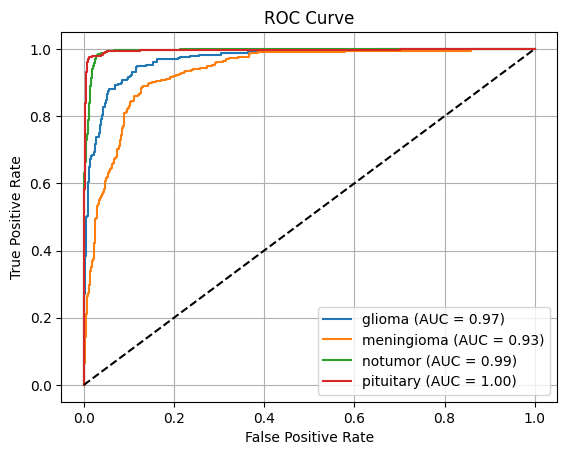

In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


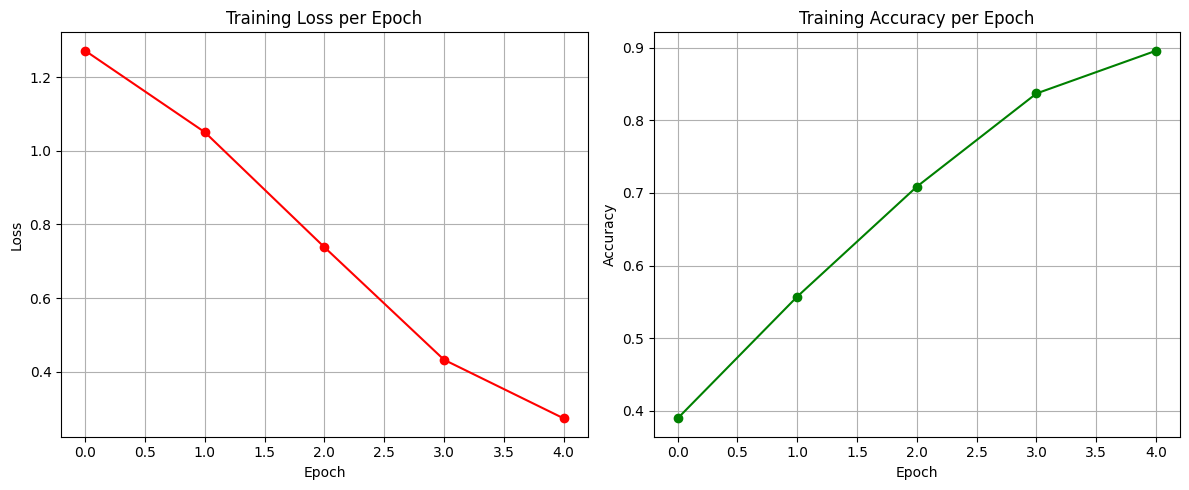

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', color='red')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, marker='o', color='green')
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


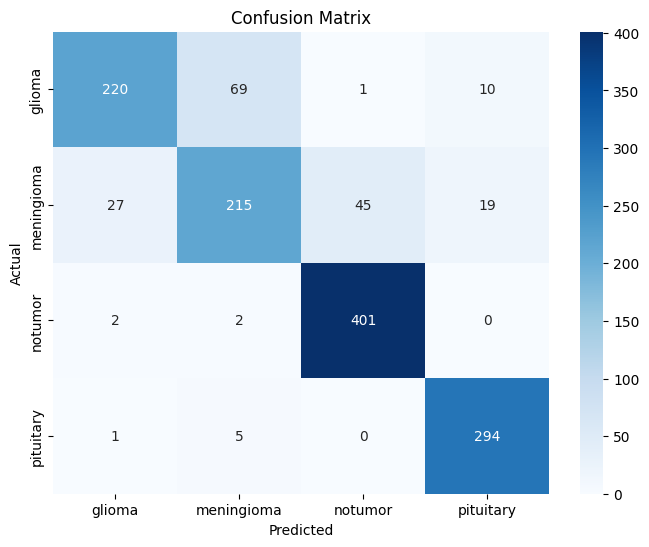

In [13]:
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



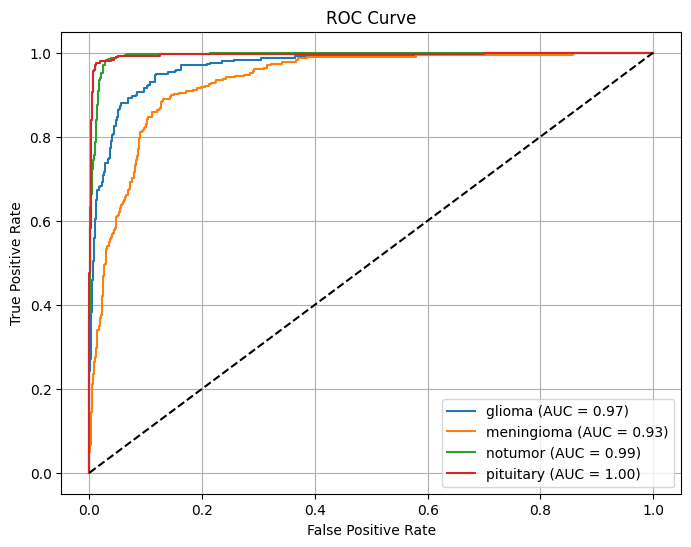

In [14]:
plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()


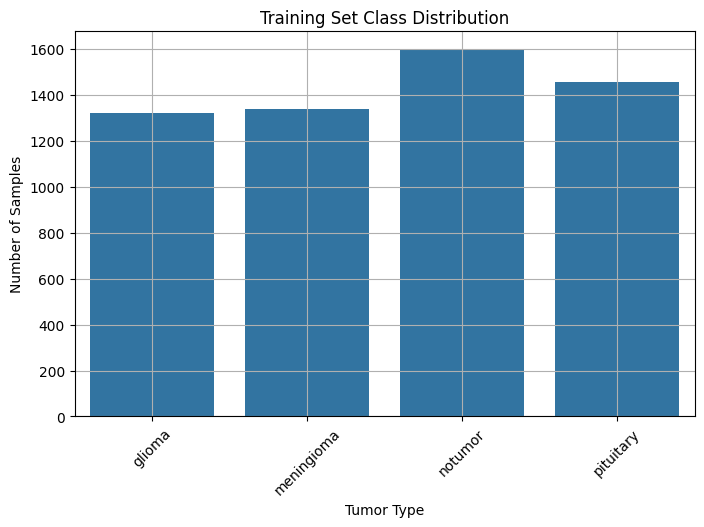

In [15]:
from collections import Counter
import pandas as pd

# Show class distribution
counts = Counter([label for _, label in train_dataset])
class_dist = pd.DataFrame({'Class': [class_names[i] for i in counts.keys()], 'Count': list(counts.values())})

plt.figure(figsize=(8,5))
sns.barplot(x='Class', y='Count', data=class_dist)
plt.title("Training Set Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
    